## EDA & Pre-processing: Customer Segmentation in Digital Marketing
**Referensi Paper:** Wang, G. (2025). *Customer segmentation in the digital marketing using a Q-learning based differential evolution algorithm integrated with K-means clustering.* PLoS ONE 20(2): e0318519. https://doi.org/10.1371/journal.pone.0318519

**Tujuan Notebook:**

1. Memuat dataset Kaggle e-commerce dan melakukan pembersihan data awal.
2. Mengekstrak **11 fitur baru** menggunakan pendekatan RFM (Recency, Frequency, Monetary) sesuai Tabel 1 pada paper.
3. Melakukan **Z-score normalization** sesuai Persamaan (14) pada paper.
4. Menganalisis **matriks korelasi** antar fitur untuk mengidentifikasi redundansi dan multikolinearitas.
5. Menerapkan **Principal Component Analysis (PCA)** untuk reduksi dimensi — memilih komponen yang menjelaskan ≥ 90% variance kumulatif (Section 3.1 paper).
6. Memvisualisasikan kontribusi fitur pada setiap komponen utama.

---
**Catatan Metodologi:**
- Fitur dibangun dari 8 kolom asli: `InvoiceNo`, `StockCode`, `Description`, `Quantity`, `InvoiceDate`, `UnitPrice`, `CustomerID`, `Country`
- Transformasi fitur mengikuti **Tabel 1** dan **Bagian 4.1** paper secara verbatim
- Reduksi dimensi mengikuti **Bagian 3.1** dan **Gambar 8** paper


In [1]:
# ============================================================
# Import library esensial
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi visualisasi global
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size']  = 11

print("Library berhasil diimport.")


Library berhasil diimport.


In [2]:
# ============================================================
# Memuat dataset
# Pastikan path disesuaikan dengan struktur repositori
# Dataset: Kaggle E-Commerce Customer Segmentation
# Sumber: https://www.kaggle.com/code/fabiendaniel/customer-segmentation/notebook
# ============================================================
file_path = '../data/raw/data.csv'
df = pd.read_csv(file_path, encoding='ISO-8859-1')

print(f"Dimensi data awal : {df.shape}")
print(f"Kolom             : {list(df.columns)}")
print(f"\nMissing values :")
print(df.isnull().sum().to_string())
df.head()


Dimensi data awal : (541909, 8)
Kolom             : ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Missing values :
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## 1. Data Cleaning

Langkah-langkah pembersihan data awal sebelum feature engineering:

1. **Hapus baris tanpa `CustomerID`** — tidak dapat dikaitkan ke pelanggan manapun
2. **Parse tipe data** — `InvoiceNo` sebagai string, `InvoiceDate` sebagai datetime
3. **Filter `StockCode`** — hanya produk nyata (format ≥ 5 digit angka), menghilangkan kode internal seperti `POST`, `DOT`, `AMAZONFEE`, dll.
4. **Buat kolom `TotalPrice`** = `Quantity × UnitPrice`

> **Catatan:** Transaksi pembatalan (prefix `C` pada `InvoiceNo`) **tidak dihapus** di tahap ini karena akan diekstrak sebagai fitur `Var 10` (Transaction cancellation frequency) pada tahap berikutnya.


In [3]:
# --- Step 1: Hapus CustomerID kosong ---
df_clean = df.dropna(subset=['CustomerID']).copy()
df_clean['InvoiceNo']   = df_clean['InvoiceNo'].astype(str)
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

n_before       = len(df)
n_after_cid    = len(df_clean)

# --- Step 2: Filter StockCode produk nyata (>= 5 digit angka) ---
df_clean       = df_clean[df_clean['StockCode'].str.contains(r'^\d{5}', na=False, regex=True)]
n_after_stock  = len(df_clean)

# --- Step 3: Buat TotalPrice ---
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print("=== Ringkasan Data Cleaning ===")
print(f"  Baris awal                 : {n_before:>8,}")
print(f"  Setelah hapus null CustID : {n_after_cid:>8,}  (dihapus: {n_before - n_after_cid:,})")
print(f"  Setelah filter StockCode  : {n_after_stock:>8,}  (dihapus: {n_after_cid - n_after_stock:,})")
print(f"  Total baris dihapus       : {n_before - n_after_stock:>8,} ({(n_before - n_after_stock)/n_before*100:.1f}%)")


=== Ringkasan Data Cleaning ===
  Baris awal                 :  541,909
  Setelah hapus null CustID :  406,829  (dihapus: 135,080)
  Setelah filter StockCode  :  404,909  (dihapus: 1,920)
  Total baris dihapus       :  137,000 (25.3%)


## 2. Feature Engineering — Ekstraksi 11 Fitur (Tabel 1 Paper)

Sesuai **Tabel 1** pada paper (Section 4), fitur-fitur asli ditransformasi menjadi 11 representasi yang lebih bermakna:

| No. | Fitur  | Deskripsi                                              | Sumber   |
|-----|--------|--------------------------------------------------------|----------|
| 1   | Var 1  | Jumlah hari sejak transaksi terakhir (Recency)         | RFM      |
| 2   | Var 2  | Total jumlah transaksi (Frequency)                     | RFM      |
| 3   | Var 3  | Total jumlah produk yang dibeli pelanggan              | Tambahan |
| 4   | Var 4  | Total pengeluaran atas item yang dibeli (Monetary)     | RFM      |
| 5   | Var 5  | Rata-rata biaya per transaksi                          | Tambahan |
| 6   | Var 6  | Jumlah tipe produk yang dibeli                         | Tambahan |
| 7   | Var 7  | Rata-rata jumlah hari antar pembelian                  | Tambahan |
| 8   | Var 8  | Perkiraan hari pembelian berikutnya                    | Tambahan |
| 9   | Var 9  | Berasal dari negara UK (binary)                        | Tambahan |
| 10  | Var 10 | Frekuensi pembatalan transaksi                         | Tambahan |
| 11  | Var 11 | Rata-rata pengeluaran bulanan                          | Tambahan |

> **Justifikasi `Var 10` (CancelFrequency):** Dihitung dari `df_clean` sebelum filter sukses karena kita ingin menangkap *perilaku pembatalan* pelanggan — fitur behavioral yang valid dan bermakna untuk segmentasi.


In [4]:
# ============================================================
# Ekstraksi Var 10 (CancelFrequency) dari df_clean
# Justifikasi: df_clean masih mengandung transaksi cancel (prefix 'C')
# yang merupakan perilaku behavioral pelanggan yang ingin ditangkap
# ============================================================
df_clean['IsCanceled'] = df_clean['InvoiceNo'].str.startswith('C')
cancellations = (
    df_clean[df_clean['IsCanceled']]
    .groupby('CustomerID')['InvoiceNo']
    .nunique()
    .reset_index()
    .rename(columns={'InvoiceNo': 'CancelFrequency'})
)

# --- Filter ke transaksi sukses untuk agregasi RFM utama ---
df_success    = df_clean[(~df_clean['IsCanceled']) & (df_clean['Quantity'] > 0)].copy()
snapshot_date = df_success['InvoiceDate'].max() + timedelta(days=1)

# --- Agregasi fitur per pelanggan ---
customer_df = df_success.groupby('CustomerID').agg(
    Var1   = ('InvoiceDate',  lambda x: (snapshot_date - x.max()).days),   # Recency
    Var2   = ('InvoiceNo',    'nunique'),                                   # Frequency
    Var3   = ('Quantity',     'sum'),                                       # Total products
    Var4   = ('TotalPrice',   'sum'),                                       # Monetary
    Var5   = ('TotalPrice',   'mean'),                                      # Avg transaction cost
    Var6   = ('StockCode',    'nunique'),                                   # Unique product types
    first  = ('InvoiceDate',  'min'),
    last   = ('InvoiceDate',  'max')
).reset_index()

# Var7: Rata-rata hari antar pembelian
# Dihitung dari selisih (last - first) / (frequency - 1), minimal 1 hari
customer_df['Var7'] = (
    (customer_df['last'] - customer_df['first']).dt.days
    / (customer_df['Var2'] - 1).clip(lower=1)
)

# Var8: Perkiraan hari pembelian berikutnya = Recency + Var7
customer_df['Var8'] = customer_df['Var1'] + customer_df['Var7']

# Var9: Asal negara UK (binary 0/1)
uk_customers = (
    df_success[df_success['Country'] == 'United Kingdom']
    .groupby('CustomerID')
    .size()
    .reset_index(name='uk_count')
)
customer_df = customer_df.merge(uk_customers[['CustomerID']], on='CustomerID', how='left', indicator=True)
customer_df['Var9'] = (customer_df['_merge'] == 'both').astype(int)
customer_df = customer_df.drop(columns=['_merge'])

# Var10: Frekuensi pembatalan transaksi
customer_df = customer_df.merge(cancellations, on='CustomerID', how='left')
customer_df['CancelFrequency'] = customer_df['CancelFrequency'].fillna(0)
customer_df = customer_df.rename(columns={'CancelFrequency': 'Var10'})

# Var11: Rata-rata pengeluaran bulanan
customer_df['CustomerAgeMonths'] = (
    (customer_df['last'] - customer_df['first']).dt.days / 30
).clip(lower=1)
customer_df['Var11'] = customer_df['Var4'] / customer_df['CustomerAgeMonths']

# --- Finalisasi: ambil hanya 11 fitur, set index ---
feature_cols = [f'Var{i}' for i in range(1, 12)]
customer_df  = customer_df.set_index('CustomerID')[feature_cols]

print(f"Jumlah pelanggan unik : {len(customer_df):,}")
print(f"Fitur yang diekstrak  : {list(customer_df.columns)}")
print(f"\nStatistik deskriptif (nilai mentah):")
customer_df.describe().round(2)


Jumlah pelanggan unik : 4,335
Fitur yang diekstrak  : ['Var1', 'Var2', 'Var3', 'Var4', 'Var5', 'Var6', 'Var7', 'Var8', 'Var9', 'Var10', 'Var11']

Statistik deskriptif (nilai mentah):


,Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8,Var9,Var10,Var11
count,4335.00,4335.00,4335.0,4335.00,4335.00,4335.00,4335.00,4335.00,4335.0,4335.00,4335.00
mean,92.68,4.25,1192.9,2021.01,67.94,61.41,47.55,140.23,0.9,0.77,440.23
std,100.17,7.64,5052.5,8906.53,1468.61,85.30,63.23,103.26,0.3,1.97,1622.88
min,1.00,1.00,1.0,0.00,0.00,1.00,0.00,1.00,0.0,0.00,0.00
25%,18.00,1.00,160.0,305.41,12.24,16.00,0.00,54.19,1.0,0.00,132.67
50%,51.00,2.00,379.0,668.11,17.56,35.00,28.08,110.25,1.0,0.00,241.06
75%,143.00,5.00,992.5,1631.48,24.61,77.00,68.45,213.50,1.0,1.00,420.54
max,374.00,206.00,197420.0,279138.02,77183.60,1785.00,365.00,374.00,1.0,45.00,77183.60


## 3. Z-Score Normalization (Persamaan 14 — Section 4.1 Paper)

Sesuai **Section 4.1** paper, normalisasi Z-score diterapkan sebelum analisis korelasi dan PCA:

$$X = \frac{X_o - \mu}{\sigma}$$

di mana:
- $X$ = dataset yang telah dinormalisasi
- $X_o$ = dataset asli
- $\mu$ = vektor mean tiap fitur
- $\sigma$ = vektor standar deviasi tiap fitur

> **Tujuan:** Membawa semua fitur ke skala yang sama sehingga setiap fitur berkontribusi secara setara dalam analisis. Proses ini mengurangi instabilitas numerik dan meningkatkan performa model clustering.


In [5]:
# ============================================================
# Z-Score Normalization — Persamaan (14) paper
# X = (Xo - mu) / sigma
# ============================================================
scaler     = StandardScaler()
scaled_arr = scaler.fit_transform(customer_df)
scaled_df  = pd.DataFrame(scaled_arr, columns=customer_df.columns, index=customer_df.index)

# Verifikasi hasil normalisasi
print("=== Verifikasi Z-Score Normalization ===")
print(f"\nMean tiap fitur (harus mendekati 0.0):")
print(scaled_df.mean().round(6).to_string())
print(f"\nStd tiap fitur (harus mendekati 1.0):")
print(scaled_df.std().round(6).to_string())
print(f"\nShape data ternormalisasi: {scaled_df.shape}")
scaled_df.describe().round(4)


=== Verifikasi Z-Score Normalization ===

Mean tiap fitur (harus mendekati 0.0):
Var1    -0.0
Var2    -0.0
Var3    -0.0
Var4    -0.0
Var5    -0.0
Var6    -0.0
Var7    -0.0
Var8     0.0
Var9     0.0
Var10   -0.0
Var11   -0.0

Std tiap fitur (harus mendekati 1.0):
Var1     1.000115
Var2     1.000115
Var3     1.000115
Var4     1.000115
Var5     1.000115
Var6     1.000115
Var7     1.000115
Var8     1.000115
Var9     1.000115
Var10    1.000115
Var11    1.000115

Shape data ternormalisasi: (4335, 11)


,Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8,Var9,Var10,Var11
count,4335.0000,4335.0000,4335.0000,4335.0000,4335.0000,4335.0000,4335.0000,4335.0000,4335.0000,4335.0000,4335.0000
mean,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.0000,0.0000,-0.0000,-0.0000
std,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001
min,-0.9154,-0.4251,-0.2359,-0.2269,-0.0463,-0.7083,-0.7520,-1.3486,-3.0612,-0.3924,-0.2713
25%,-0.7456,-0.4251,-0.2045,-0.1926,-0.0379,-0.5324,-0.7520,-0.8334,0.3267,-0.3924,-0.1895
50%,-0.4162,-0.2941,-0.1611,-0.1519,-0.0343,-0.3097,-0.3079,-0.2904,0.3267,-0.3924,-0.1227
75%,0.5023,0.0988,-0.0397,-0.0437,-0.0295,0.1827,0.3306,0.7097,0.3267,0.1151,-0.0121
max,2.8086,26.4233,38.8421,31.1175,52.5155,20.2075,5.0210,2.2642,0.3267,22.4459,47.2939


## 4. Analisis Matriks Korelasi (Section 4.1 — Gambar 7 Paper)

Sesuai **Section 4.1** paper, matriks korelasi digunakan untuk:
- Mengidentifikasi **fitur redundan** dan **multikolinear** dalam dataset
- Mendeteksi pola hubungan antar variabel sebelum PCA

Dari analisis paper: *"terdapat korelasi signifikan antar variabel. Misalnya, Var 1 menunjukkan korelasi positif kuat dengan Var 2, Var 3, Var 5, dan Var 9."*

> **Konvensi warna (mengacu Gambar 7 paper):**
> - Blok kuning lebih gelap → korelasi positif lebih kuat
> - Blok biru lebih gelap → korelasi negatif lebih kuat


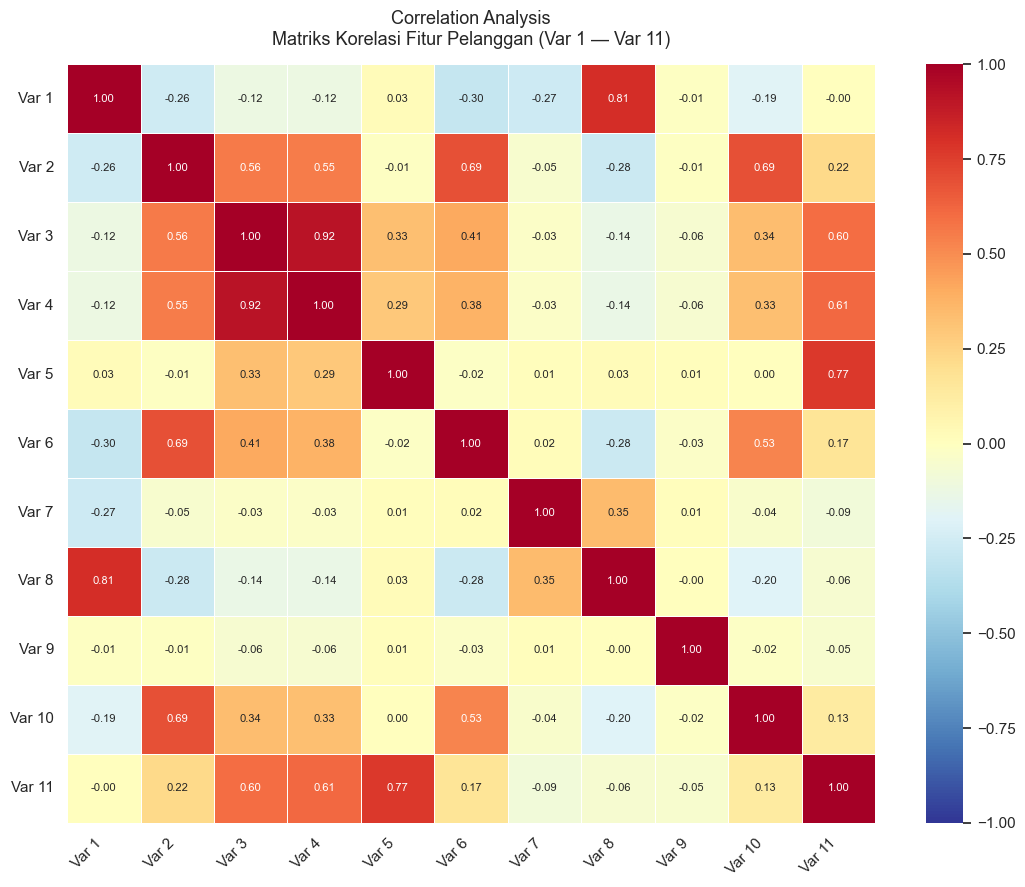


Pasangan fitur dengan korelasi tinggi (|r| > 0.6):
  Var3   <-> Var4    r = +0.920
  Var1   <-> Var8    r = +0.810
  Var11  <-> Var5    r = +0.770
  Var2   <-> Var6    r = +0.690
  Var10  <-> Var2    r = +0.690
  Var11  <-> Var4    r = +0.610


In [6]:
# ============================================================
# Matriks Korelasi antar Fitur Pelanggan
# Sesuai Gambar 7 pada paper (Section 4.1)
# ============================================================
corr_matrix = scaled_df.corr().round(2)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='RdYlBu_r',        # kuning = positif, biru = negatif (sesuai paper)
    fmt='.2f',
    linewidths=0.5,
    annot_kws={'size': 8},
    vmin=-1, vmax=1,
    ax=ax
)
ax.set_title('Correlation Analysis\nMatriks Korelasi Fitur Pelanggan (Var 1 — Var 11)',
             fontsize=13, pad=14)
ax.set_xticklabels([f'Var {i}' for i in range(1, 12)], rotation=45, ha='right')
ax.set_yticklabels([f'Var {i}' for i in range(1, 12)], rotation=0)
plt.tight_layout()
plt.show()

# Highlight pasangan dengan korelasi tinggi (|r| > 0.6)
high_corr = [
    (i, j, corr_matrix.loc[i, j])
    for i in corr_matrix.columns
    for j in corr_matrix.columns
    if i < j and abs(corr_matrix.loc[i, j]) > 0.6
]
if high_corr:
    print("\nPasangan fitur dengan korelasi tinggi (|r| > 0.6):")
    for a, b, r in sorted(high_corr, key=lambda x: -abs(x[2])):
        print(f"  {a:6s} <-> {b:6s}  r = {r:+.3f}")
else:
    print("\nTidak ada pasangan fitur dengan |r| > 0.6")


## 5. Principal Component Analysis — PCA (Section 3.1 Paper)

Sesuai **Section 3.1** paper, PCA diterapkan sebagai strategi reduksi dimensi:

**Prosedur PCA (mengikuti paper):**
1. **Normalisasi data** ✅ (sudah dilakukan di langkah sebelumnya)
2. **Hitung matriks kovarians** dari dataset
3. **Dekomposisi nilai eigen** untuk mengekstrak eigenvectors dan eigenvalues
4. **Pilih komponen utama** berdasarkan variance kumulatif ≥ 90% (threshold paper)

**Kriteria seleksi komponen (Gambar 8a paper):**
> *"Untuk memastikan clustering efektif dan meminimalkan noise data, 6 komponen utama pertama yang menjelaskan lebih dari 90% variance yang dijelaskan, dipilih sebagai input."*

Selanjutnya, **Gambar 8b** pada paper menunjukkan kontribusi variabel asli terhadap setiap komponen utama (PCA loading).


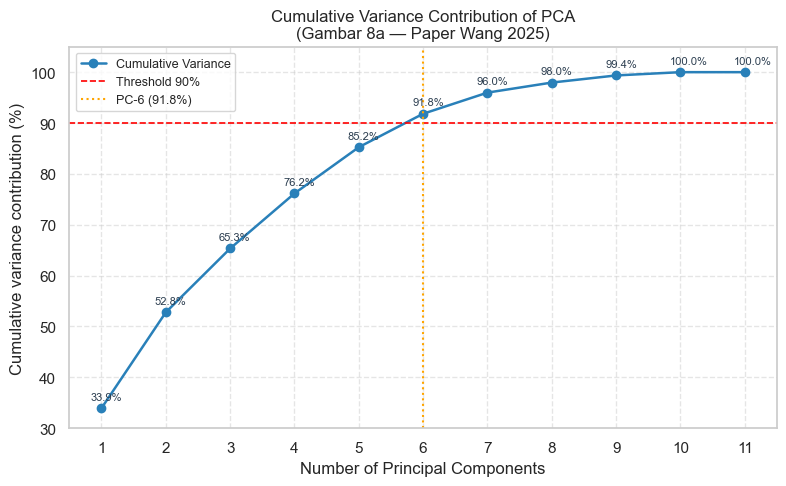

Jumlah komponen yang menjelaskan ≥ 90% variance: 6 komponen

Variance per komponen (%):
  PC- 1  :  33.93%   kumulatif:  33.93%
  PC- 2  :  18.85%   kumulatif:  52.78%
  PC- 3  :  12.55%   kumulatif:  65.33%
  PC- 4  :  10.83%   kumulatif:  76.16%
  PC- 5  :   9.09%   kumulatif:  85.25%
  PC- 6  :   6.58%   kumulatif:  91.83% ← dipilih (kumulatif ≥ 90%)
  PC- 7  :   4.16%   kumulatif:  95.98%
  PC- 8  :   1.97%   kumulatif:  97.96%
  PC- 9  :   1.40%   kumulatif:  99.36%
  PC-10  :   0.64%   kumulatif: 100.00%
  PC-11  :   0.00%   kumulatif: 100.00%


In [7]:
# ============================================================
# PCA — Fit pada semua komponen terlebih dahulu
# untuk menentukan jumlah komponen optimal
# Sesuai Section 3.1 dan Gambar 8a paper
# ============================================================
pca_full = PCA(random_state=42)
pca_full.fit(scaled_df)

explained_var   = pca_full.explained_variance_ratio_ * 100
cumulative_var  = np.cumsum(explained_var)
n_components_total = len(explained_var)

# --- Gambar 8a: Cumulative Variance Contribution of PCA ---
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    range(1, n_components_total + 1), cumulative_var,
    marker='o', markersize=6, linewidth=1.8,
    color='#2980b9', label='Cumulative Variance'
)

# Tandai setiap titik dengan nilai
for i, val in enumerate(cumulative_var):
    ax.annotate(
        f'{val:.1f}%',
        (i + 1, val),
        textcoords='offset points',
        xytext=(-8, 6),
        fontsize=8,
        color='#2c3e50'
    )

# Garis threshold 90%
ax.axhline(90, color='red', linestyle='--', linewidth=1.2, label='Threshold 90%')

# Temukan komponen ke berapa pertama kali ≥ 90%
n_comp_90 = int(np.argmax(cumulative_var >= 90)) + 1
ax.axvline(n_comp_90, color='orange', linestyle=':', linewidth=1.5,
           label=f'PC-{n_comp_90} ({cumulative_var[n_comp_90-1]:.1f}%)')

ax.set_title('Cumulative Variance Contribution of PCA\n(Gambar 8a — Paper Wang 2025)',
             fontsize=12)
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative variance contribution (%)')
ax.set_xticks(range(1, n_components_total + 1))
ax.set_ylim(30, 105)
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Jumlah komponen yang menjelaskan ≥ 90% variance: {n_comp_90} komponen")
print(f"\nVariance per komponen (%):")
for i, v in enumerate(explained_var):
    cum = cumulative_var[i]
    mark = " ← dipilih (kumulatif ≥ 90%)" if i + 1 == n_comp_90 else ""
    print(f"  PC-{i+1:2d}  : {v:6.2f}%   kumulatif: {cum:6.2f}%{mark}")


In [8]:
# ============================================================
# Terapkan PCA dengan jumlah komponen optimal (n_comp_90)
# Sesuai kriteria paper: komponen yang menjelaskan ≥ 90% variance kumulatif
# ============================================================
n_selected   = n_comp_90   # mengikuti hasil dari sel sebelumnya (biasanya = 6)
pca_selected = PCA(n_components=n_selected, random_state=42)
pca_data     = pca_selected.fit_transform(scaled_df)

# Buat DataFrame hasil PCA
pca_cols = [f'PCA {i}' for i in range(1, n_selected + 1)]
pca_df   = pd.DataFrame(pca_data, columns=pca_cols, index=scaled_df.index)

print(f"=== Hasil PCA ===")
print(f"  Dimensi asli          : {scaled_df.shape[1]} fitur")
print(f"  Komponen terpilih     : {n_selected} PC")
print(f"  Variance dijelaskan   : {pca_selected.explained_variance_ratio_.sum()*100:.2f}%")
print(f"  Shape output PCA      : {pca_df.shape}")
print(f"\nVariance tiap PC yang dipilih:")
for i, v in enumerate(pca_selected.explained_variance_ratio_):
    print(f"  {pca_cols[i]}: {v*100:.2f}%")
pca_df.head()


=== Hasil PCA ===
  Dimensi asli          : 11 fitur
  Komponen terpilih     : 6 PC
  Variance dijelaskan   : 91.83%
  Shape output PCA      : (4335, 6)

Variance tiap PC yang dipilih:
  PCA 1: 33.93%
  PCA 2: 18.85%
  PCA 3: 12.55%
  PCA 4: 10.83%
  PCA 5: 9.09%
  PCA 6: 6.58%


,PCA 1,PCA 2,PCA 3,PCA 4,PCA 5,PCA 6
CustomerID,,,,,,
12346.0,33.249579,52.551842,-26.590693,7.151144,4.475082,24.727561
12347.0,0.816040,-0.628254,-0.524770,0.181634,-3.121962,-0.018666
12348.0,-0.258863,0.290840,0.153847,0.543679,-3.121974,-0.027804
12349.0,0.378307,-0.315472,-1.386997,-0.767695,-3.082350,0.279678
12350.0,-1.358794,1.865529,1.564444,-1.409774,-2.846710,0.349605


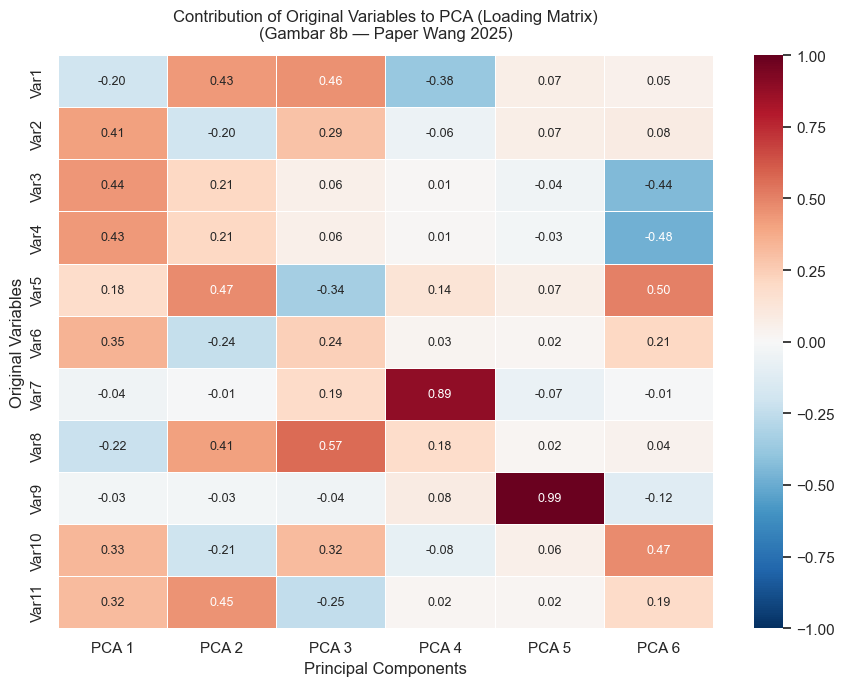


Loading matrix (kontribusi variabel asli ke setiap PC):
       PCA 1  PCA 2  PCA 3  PCA 4  PCA 5  PCA 6
Var1   -0.20   0.43   0.46  -0.38   0.07   0.05
Var2    0.41  -0.20   0.29  -0.06   0.07   0.08
Var3    0.44   0.21   0.06   0.01  -0.04  -0.44
Var4    0.43   0.21   0.06   0.01  -0.03  -0.48
Var5    0.18   0.47  -0.34   0.14   0.07   0.50
Var6    0.35  -0.24   0.24   0.03   0.02   0.21
Var7   -0.04  -0.01   0.19   0.89  -0.07  -0.01
Var8   -0.22   0.41   0.57   0.18   0.02   0.04
Var9   -0.03  -0.03  -0.04   0.08   0.99  -0.12
Var10   0.33  -0.21   0.32  -0.08   0.06   0.47
Var11   0.32   0.45  -0.25   0.02   0.02   0.19


In [9]:
# ============================================================
# Gambar 8b: Kontribusi Variabel Asli pada PCA (Loading Matrix)
# Sesuai paper: "principal components effectively represent
# the various characteristics of the original customers"
# ============================================================
loadings_df = pd.DataFrame(
    pca_selected.components_.T,
    index=customer_df.columns,
    columns=[f'PCA {i}' for i in range(1, n_selected + 1)]
).round(2)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    loadings_df,
    annot=True,
    cmap='RdBu_r',
    fmt='.2f',
    linewidths=0.5,
    annot_kws={'size': 9},
    vmin=-1, vmax=1,
    ax=ax
)
ax.set_title(
    'Contribution of Original Variables to PCA (Loading Matrix)\n(Gambar 8b — Paper Wang 2025)',
    fontsize=12, pad=12
)
ax.set_xlabel('Principal Components')
ax.set_ylabel('Original Variables')
plt.tight_layout()
plt.show()

print("\nLoading matrix (kontribusi variabel asli ke setiap PC):")
print(loadings_df.to_string())


## 6. Exploratory Data Analysis (EDA) — Distribusi Fitur

Visualisasi distribusi 11 fitur hasil feature engineering untuk memahami karakteristik data pelanggan sebelum dan sesudah normalisasi.


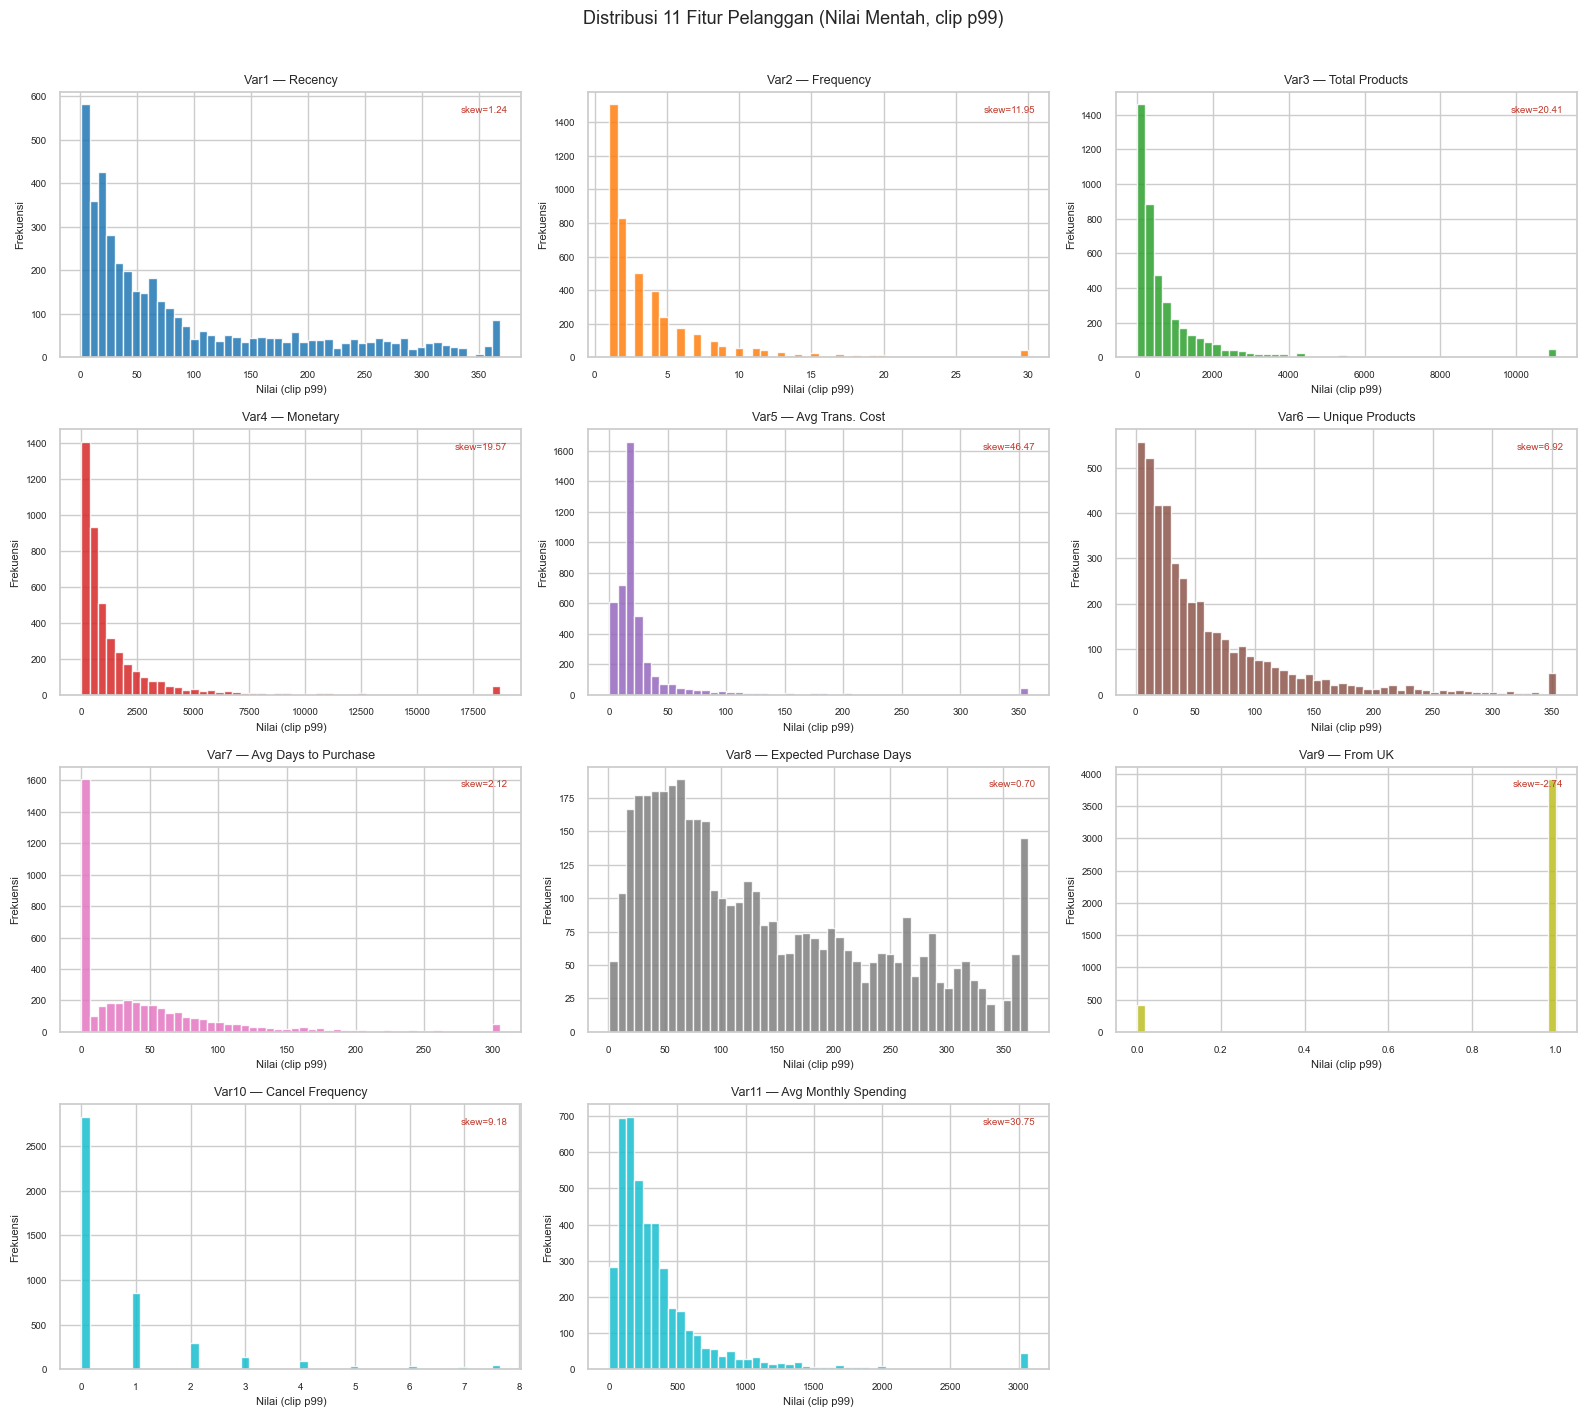

In [10]:
# ============================================================
# EDA: Distribusi 11 Fitur (sebelum normalisasi — nilai mentah)
# ============================================================
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

colors = plt.cm.tab10(np.linspace(0, 1, 11))

for i, col in enumerate(customer_df.columns):
    axes[i].hist(
        customer_df[col].clip(upper=customer_df[col].quantile(0.99)),
        bins=50, color=colors[i], edgecolor='white', alpha=0.85
    )
    axes[i].set_title(f'{col} — {["Recency","Frequency","Total Products","Monetary","Avg Trans. Cost","Unique Products","Avg Days to Purchase","Expected Purchase Days","From UK","Cancel Frequency","Avg Monthly Spending"][i]}',
                      fontsize=9)
    axes[i].set_xlabel('Nilai (clip p99)', fontsize=8)
    axes[i].set_ylabel('Frekuensi', fontsize=8)
    axes[i].tick_params(labelsize=7)
    skew_val = customer_df[col].skew()
    axes[i].annotate(f'skew={skew_val:.2f}', xy=(0.97, 0.95), xycoords='axes fraction',
                      ha='right', va='top', fontsize=7, color='#c0392b')

# Sembunyikan axes kosong (grid 4x3 = 12, fitur = 11)
axes[11].set_visible(False)

fig.suptitle('Distribusi 11 Fitur Pelanggan (Nilai Mentah, clip p99)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


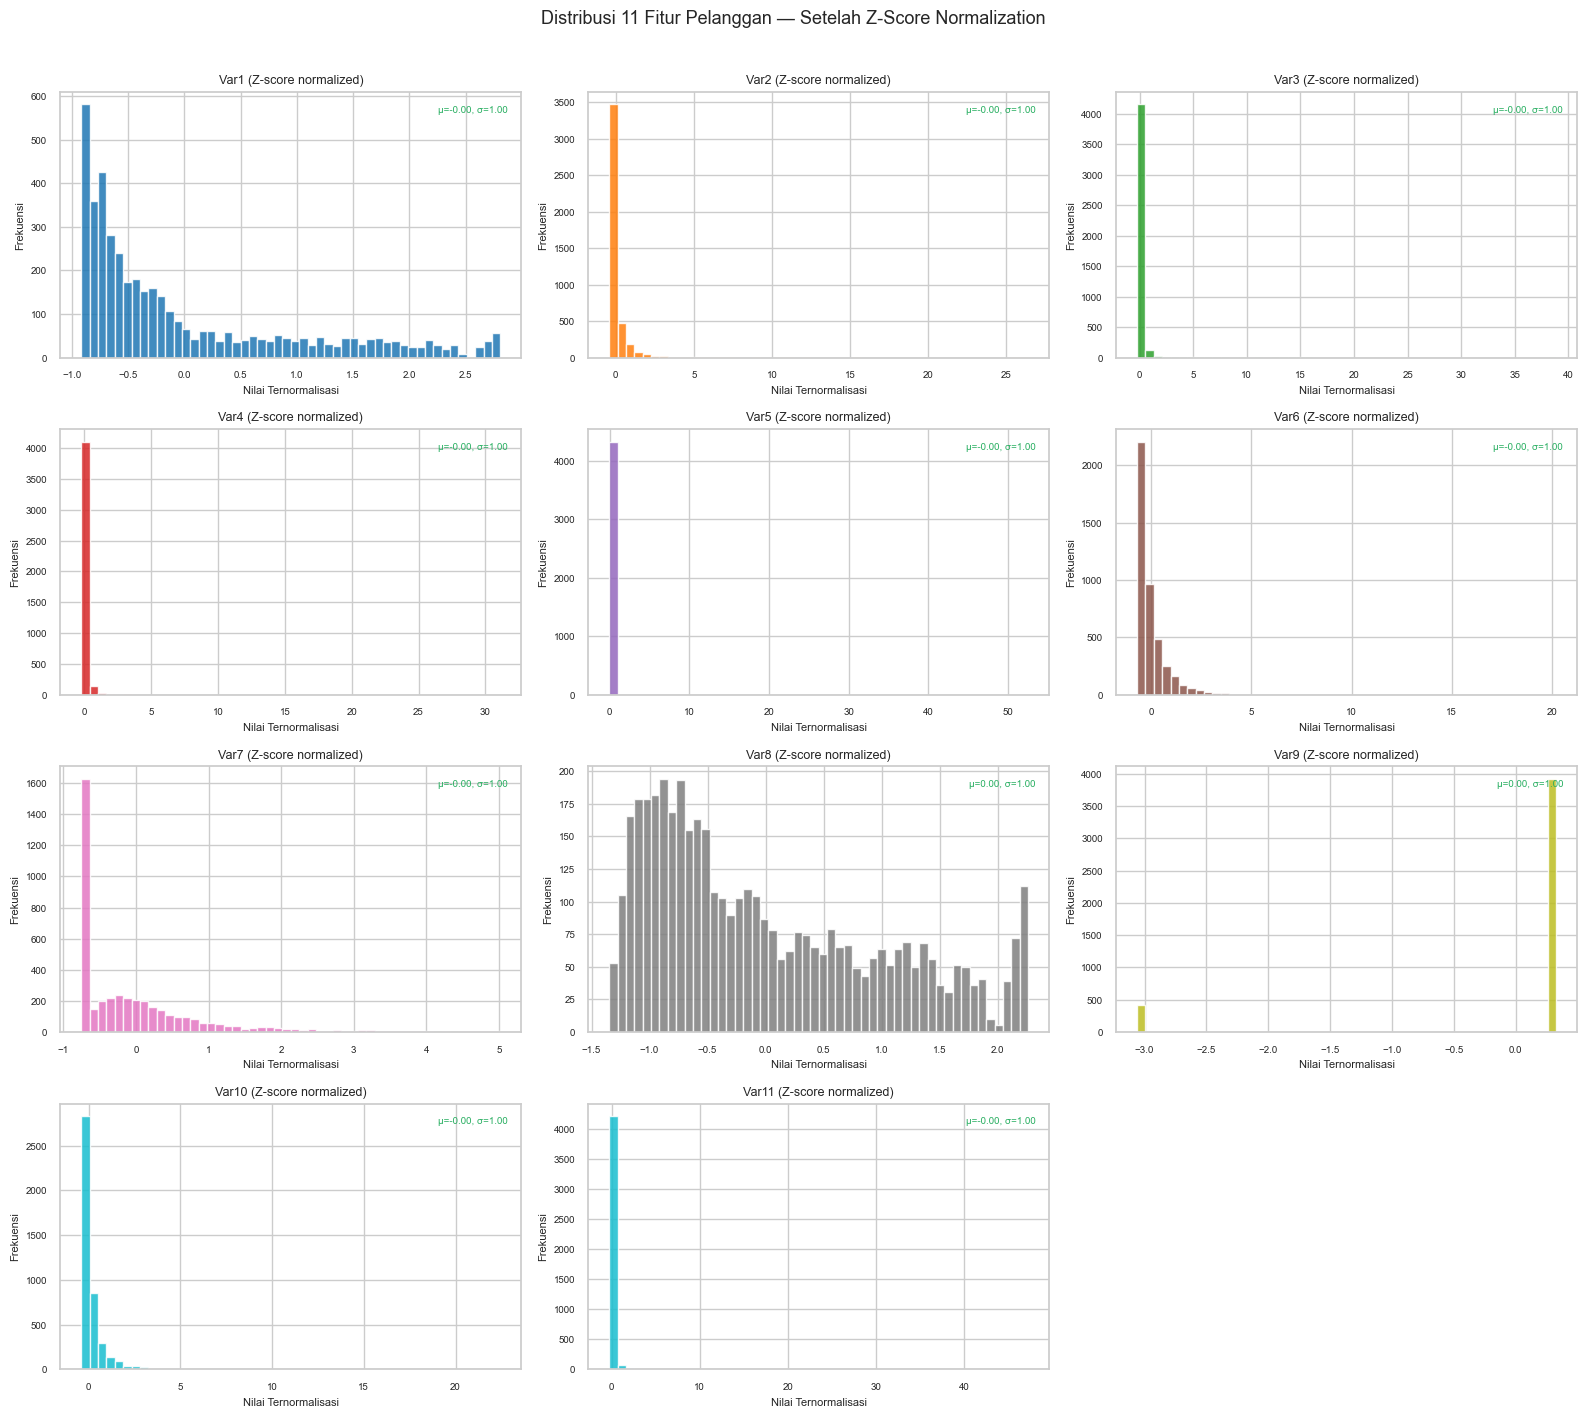

In [11]:
# ============================================================
# EDA: Distribusi 11 Fitur SETELAH Z-Score Normalization
# Memverifikasi bahwa normalisasi berjalan benar (mean≈0, std≈1)
# ============================================================
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(scaled_df.columns):
    axes[i].hist(
        scaled_df[col],
        bins=50, color=colors[i], edgecolor='white', alpha=0.85
    )
    axes[i].set_title(f'{col} (Z-score normalized)', fontsize=9)
    axes[i].set_xlabel('Nilai Ternormalisasi', fontsize=8)
    axes[i].set_ylabel('Frekuensi', fontsize=8)
    axes[i].tick_params(labelsize=7)
    mean_v = scaled_df[col].mean()
    std_v  = scaled_df[col].std()
    axes[i].annotate(f'μ={mean_v:.2f}, σ={std_v:.2f}', xy=(0.97, 0.95),
                     xycoords='axes fraction', ha='right', va='top',
                     fontsize=7, color='#27ae60')

axes[11].set_visible(False)
fig.suptitle('Distribusi 11 Fitur Pelanggan — Setelah Z-Score Normalization',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


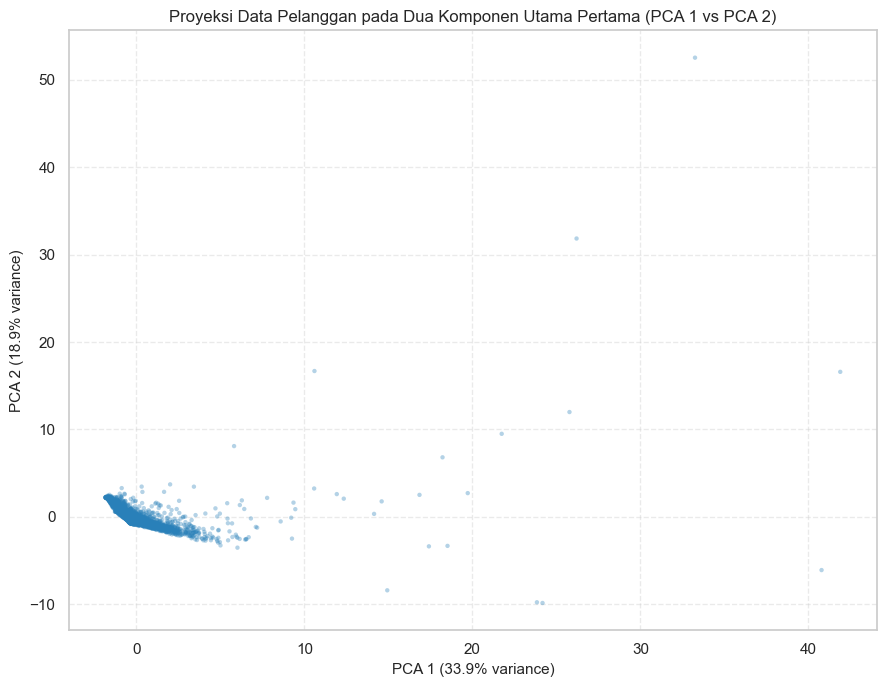

Total variance dijelaskan oleh PCA 1 + PCA 2: 52.78%


In [12]:
# ============================================================
# EDA: Visualisasi 2D pada dua PC pertama
# Proyeksi data pelanggan ke ruang komponen utama
# ============================================================
fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(
    pca_df['PCA 1'], pca_df['PCA 2'],
    alpha=0.35, s=10, c='#2980b9', edgecolors='none'
)
ax.set_xlabel(f'PCA 1 ({pca_selected.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PCA 2 ({pca_selected.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
ax.set_title('Proyeksi Data Pelanggan pada Dua Komponen Utama Pertama (PCA 1 vs PCA 2)',
             fontsize=12)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Total variance dijelaskan oleh PCA 1 + PCA 2: "
      f"{sum(pca_selected.explained_variance_ratio_[:2])*100:.2f}%")


## 7. Ringkasan & Simpulan EDA/Preprocessing

Tabel ringkasan proses yang telah dilakukan sesuai paper:

| Tahap | Metode | Output |
|-------|--------|--------|
| Data Cleaning | Hapus null CustomerID, filter StockCode | Dataset bersih |
| Feature Engineering | RFM + 8 fitur tambahan (Tabel 1 paper) | 11 fitur per pelanggan |
| Normalisasi | Z-score (Persamaan 14) | `scaled_df` |
| Analisis Korelasi | Matriks korelasi (Gambar 7) | Identifikasi fitur redundan |
| Reduksi Dimensi | PCA — 6 PC pertama (≥ 90% variance) | `pca_df` |

Data `pca_df` siap digunakan sebagai **input untuk K-means-QLDE Clustering** pada notebook berikutnya.


In [13]:
# ============================================================
# Export hasil preprocessing untuk tahap clustering
# ============================================================
import os, joblib

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# 1. Fitur asli (mentah) per pelanggan — 11 fitur Tabel 1
customer_df.to_csv('../data/processed/customer_features_raw.csv')

# 2. Fitur ternormalisasi (Z-score) — 11 fitur
scaled_df.to_csv('../data/processed/customer_features_scaled.csv')

# 3. Fitur setelah PCA — n_comp_90 komponen
pca_df.to_csv('../data/processed/customer_features_pca.csv')

# 4. Simpan scaler dan PCA object untuk deployment
joblib.dump(scaler,       '../models/standard_scaler.pkl')
joblib.dump(pca_selected, '../models/pca_model.pkl')

print("=== Export Selesai ===")
print(f"  customer_features_raw.csv    : {customer_df.shape[0]:,} baris × {customer_df.shape[1]} fitur")
print(f"  customer_features_scaled.csv : {scaled_df.shape[0]:,} baris × {scaled_df.shape[1]} fitur")
print(f"  customer_features_pca.csv    : {pca_df.shape[0]:,} baris × {pca_df.shape[1]} komponen")
print(f"  standard_scaler.pkl          : tersimpan di ../models/")
print(f"  pca_model.pkl                : tersimpan di ../models/")
print("\nPreprocessing & EDA selesai. Data siap untuk K-means-QLDE Clustering.")


=== Export Selesai ===
  customer_features_raw.csv    : 4,335 baris × 11 fitur
  customer_features_scaled.csv : 4,335 baris × 11 fitur
  customer_features_pca.csv    : 4,335 baris × 6 komponen
  standard_scaler.pkl          : tersimpan di ../models/
  pca_model.pkl                : tersimpan di ../models/

Preprocessing & EDA selesai. Data siap untuk K-means-QLDE Clustering.
